# Cond-LSTM GR Bins — Local Eval

Evaluates **v2** models trained by [`train_lstm_tfilm_gr_bins.ipynb`](train_lstm_tfilm_gr_bins.ipynb)
(`model_type == "stateful_condlstm_gr_bins"`). For the earlier TFiLM-only recipe see
[`eval_lstm_tfilm_gr_bins.ipynb`](eval_lstm_tfilm_gr_bins.ipynb).

v2 changes mirrored from training:

- **Architecture**: `StatefulCondLSTMGRBins` — Fourier knob embed concatenated into the LSTM
  input every frame; optional TFiLM on top (`use_tfilm` in `hparams.json`).
- **Conditioning**: normalised param vector per setting (`splits.normalize_setting_params`,
  [`NORMALISATION.md`](NORMALISATION.md)). Guards assert `gr_range_db` / `param_ranges` match
  local `gr_target.py` / `splits.py`.
- **Discretized head**: 71 bins @ 0.5 dB over [−30, +5] dB; decode via `logits_to_local_avg_db`.
- **Stateful inference**: pre-roll warm-up; whole-song streaming carries LSTM + TFiLM states.
- **CFG** (when trained with `cond_dropout > 0`): `uncond + s · (cond − uncond)` via the learned
  null embedding — optional `cfg_scale` in `predict_gr_curves`.

> Requirements: `uv sync` at repo root. Run after the Colab run dir has synced to Drive.


In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import gc, glob, json, os, sys, types, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# stub `rational` before model.py imports nablafx (only ddsp.py needs the real one)
rational = types.ModuleType("rational")
rational.torch = types.ModuleType("rational.torch")
rational.torch.Rational = type("Rational", (), {})
sys.modules["rational"], sys.modules["rational.torch"] = rational, rational.torch

sys.path.insert(0, str(Path.cwd().parent / "03_initial_GR_pred"))  # shared eval helpers

from src.dsp_torch import gain_reduction_db
from src.losses import compute_all_losses as compute_audio_losses
from gr_target import GR_DB_MIN, GR_DB_MAX, NUM_BINS, BIN_RESOLUTION_DB
from model import StatefulCondLSTMGRBins
from splits import DIFFSSL_PARAM_RANGES, SplitManifest, normalize_setting_params
from eval_helpers import (
    _checkpoint_sort_key, _db_to_amplitude, _find_hparams_json, _pair_num_frames,
    _read_dry_wet_segment, _weighted_average_metric_rows, latest_best_checkpoint,
    list_runs, plot_loss_curves, wet_dir_for_setting,
)

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/Diff-SSL-G-Comp"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/gr_pred_runs"
SAMPLE_RATE = 44100
DEVICE = "cpu"

print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"GR range: [{GR_DB_MIN}, {GR_DB_MAX}] dB  |  {NUM_BINS} bins @ {BIN_RESOLUTION_DB:.2f} dB")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu
GR range: [-30.0, 5.0] dB  |  71 bins @ 0.50 dB


In [2]:
# ── 1. List available Cond-LSTM GR (bins) runs ───────────────────────

MODEL_TYPE = "stateful_condlstm_gr_bins"

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, f"No runs in {RUNS_DIR}"
available_models_df = runs_df[runs_df["type"] == MODEL_TYPE].copy()
assert not available_models_df.empty, (
    f"No '{MODEL_TYPE}' runs in {RUNS_DIR} — train with train_lstm_tfilm_gr_bins.ipynb first."
)

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available Cond-LSTM GR (bins) runs: {len(available_models_df)}")
display(available_models_df[display_cols])


Available Cond-LSTM GR (bins) runs: 4


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
29,lstm_gr_20260611_131613_lstm_condlstm_bins_lds...,stateful_condlstm_gr_bins,NaN,NaN,0,None,2026-06-14 12:27:35.457819700
30,lstm_gr_20260611_132049_lstm_condlstm_bins_lds...,stateful_condlstm_gr_bins,NaN,NaN,0,None,2026-06-14 12:27:35.521728039
31,lstm_gr_20260611_132330_lstm_condlstm_bins_lds...,stateful_condlstm_gr_bins,NaN,NaN,0,None,2026-06-14 12:27:35.586119413
32,lstm_gr_20260611_132730_lstm_condlstm_bins_lds...,stateful_condlstm_gr_bins,523.0,0.094211,4,best-479-456960.ckpt,2026-06-14 12:27:35.650304556


In [3]:
# ── 2. Select run, checkpoint and split manifest ─────────────────────

# Leave as None to auto-pick the most recently modified matching run.
SELECTED_RUN_NAME: str | None = None

if not SELECTED_RUN_NAME:
    selected_run = available_models_df.iloc[-1]   # list_runs sorts by mtime asc
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

with open(HPARAMS_PATH) as f:
    HP = json.load(f)
SPLIT = SplitManifest.load(os.path.join(RUN_DIR, "split_manifest.json"))

# normalisation guards — see NORMALISATION.md
assert tuple(HP["gr_range_db"]) == (GR_DB_MIN, GR_DB_MAX), HP["gr_range_db"]
assert {k: tuple(v) for k, v in HP["param_ranges"].items()} == DIFFSSL_PARAM_RANGES


def _pairs_from_keys(keys) -> list[tuple[str, str]]:
    return [tuple(k.split("::")) for k in sorted(keys)]   # (song, setting)


VAL_PAIRS = _pairs_from_keys(SPLIT.val_pair_keys)
TEST_PAIRS = _pairs_from_keys(SPLIT.test_pair_keys)

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")
print(f"Val pairs      : {len(VAL_PAIRS)}  ({SPLIT.val_songs} x all settings)")
print(f"Test pairs     : {len(TEST_PAIRS)}  ({SPLIT.test_songs} x {SPLIT.test_settings})")

Selected run   : lstm_gr_20260611_132730_lstm_condlstm_bins_lds_cdrop_coldstart
Eval checkpoint: best-479-456960.ckpt
Best val loss  : 0.094211
Val pairs      : 10  (['Ecstasy'] x all settings)
Test pairs     : 4  (['Air', 'AncoraQui'] x ['threshold_-12_attack_10_release_0.4_ratio_10', 'threshold_-12_attack_1_release_0.1_ratio_2'])


In [4]:
# ── 3. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")

Selected run   : lstm_gr_20260611_132730_lstm_condlstm_bins_lds_cdrop_coldstart
Eval checkpoint: best-479-456960.ckpt
Checkpoints    :
  last.ckpt                               0.17 MB
  best-323-308448.ckpt                    0.17 MB
  best-345-329392.ckpt                    0.17 MB
  best-479-456960.ckpt                    0.17 MB <-- eval


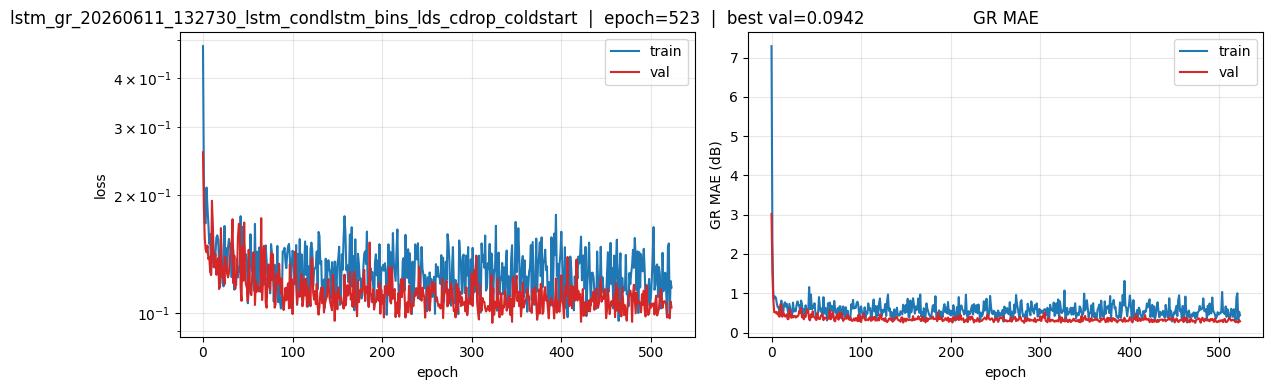

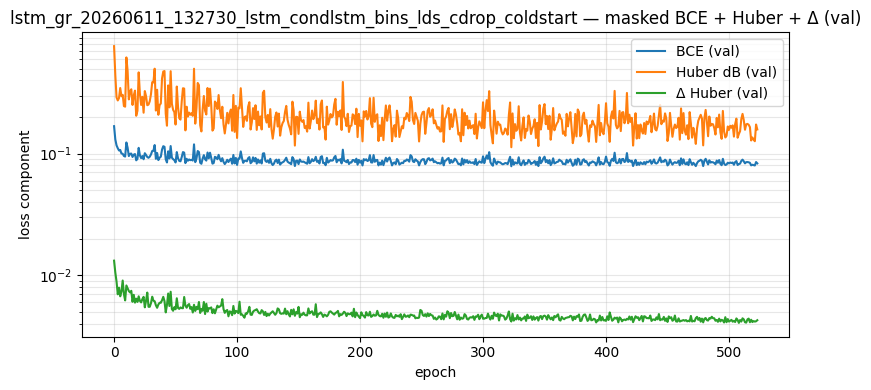

In [5]:
# ── 4. Loss curves (total + BCE / Huber / delta components) ────────

_ = plot_loss_curves(RUN_DIR)

csv_path = Path(RUN_DIR) / "csv" / "metrics.csv"
if csv_path.exists():
    _df = pd.read_csv(csv_path)
    comp_cols = [
        ("bce/val", "BCE (val)"),
        ("huber_db/val", "Huber dB (val)"),
        ("delta_db/val", "Δ Huber (val)"),
    ]
    if any(c in _df.columns for c, _ in comp_cols):
        fig, ax = plt.subplots(figsize=(8, 4))
        for col, label in comp_cols:
            if col in _df.columns:
                rows = _df.dropna(subset=[col])[["epoch", col]]
                if len(rows):
                    ax.plot(rows["epoch"], rows[col], label=label, lw=1.5)
        ax.set_xlabel("epoch")
        ax.set_ylabel("loss component")
        ax.set_yscale("log")
        ax.grid(alpha=0.3, which="both")
        ax.legend()
        ax.set_title(f"{RUN_NAME} — masked BCE + Huber + Δ (val)")
        plt.tight_layout()
        plt.show()

In [6]:
# ── 5. Checkpoint loading (StatefulCondLSTMGRBins from model.py) ─────

def _num_bins_from_hp(hp: dict) -> int:
    m = hp.get("model", {})
    d = hp.get("discretization", {})
    return int(d.get("num_bins", m.get("num_bins", NUM_BINS)))


def _reset_model_states(model) -> None:
    model.reset_cond_states()


def load_model_from_ckpt(ckpt_path, hparams_path=None):
    """Build from hparams.json and load weights (strip Lightning 'model.' prefix)."""
    hparams_path = hparams_path or _find_hparams_json(ckpt_path)
    with open(hparams_path) as f:
        hp = json.load(f)
    assert hp.get("model_type") == MODEL_TYPE, hp.get("model_type")
    m = hp["model"]
    num_bins = _num_bins_from_hp(hp)
    model = StatefulCondLSTMGRBins(
        hop_size=int(hp["hop_size"]),
        encoder_channels=int(m["encoder_channels"]),
        hidden_size=int(m["hidden_size"]),
        tfilm_channels=int(m["tfilm_channels"]),
        tfilm_block_size=int(m["tfilm_block_size"]),
        tfilm_num_layers=int(m["tfilm_num_layers"]),
        num_bins=num_bins,
        knob_freqs=int(m.get("knob_freqs", 8)),
        knob_embed_dim=int(m.get("knob_embed_dim", 16)),
        use_tfilm=bool(m.get("use_tfilm", True)),
    )
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    model.load_state_dict({k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")})
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Loaded {num_bins}-bin / {n_params:,}-param CondLSTM GR model  "
          f"(hop={model.hop_size}, use_tfilm={model.use_tfilm}, tfilm_block={model.tfilm_block_size})")
    return model, hp


MODEL, HP = load_model_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
RMS_WIN = int(HP["rms_window"])
SUPPORTS_CFG = HP.get("loss", {}).get("cond_dropout", 0) > 0
print(f"CFG available: {SUPPORTS_CFG}")


Loaded 71-bin / 11,735-param CondLSTM GR model  (hop=256, use_tfilm=True, tfilm_block=8)
CFG available: True


In [7]:
# ── 6. Prediction & visualisation (stateful, conditioned) ────────────
# Single-window prediction warms both recurrent states with a `pre_roll_sec`
# context in the SAME causal forward pass, then crops to the requested window.

DEFAULT_PRE_ROLL_SEC = 10.0


def pair_paths(setting: str, song: str) -> tuple[str, str]:
    dry = os.path.join(DATA_ROOT, "processed_normalized", f"{song}_UnmasteredWAV.wav")
    wet = os.path.join(wet_dir_for_setting(DATA_ROOT, setting), f"{song}-exported.wav")
    return dry, wet


@torch.no_grad()
def predict_gr_curves(setting, song, start_sec=0.0, duration_sec=6.0,
                      pre_roll_sec=DEFAULT_PRE_ROLL_SEC, model=None, cfg_scale: float = 1.0):
    model = model or MODEL
    sr = int(HP["sample_rate"])
    hop = model.hop_size
    dry_path, wet_path = pair_paths(setting, song)
    params = torch.tensor([normalize_setting_params(setting)], dtype=torch.float32)

    start = int(round(start_sec * sr))
    stop = start + int(round(duration_sec * sr))
    context_start = max(0, start - int(round(pre_roll_sec * sr)))
    offset = start - context_start

    dry, wet = _read_dry_wet_segment(dry_path, wet_path, context_start, stop, sr)
    gr_target_db = gain_reduction_db(
        dry.unsqueeze(0), wet.unsqueeze(0), RMS_WIN
    ).squeeze(0).clamp(GR_DB_MIN, GR_DB_MAX)

    _reset_model_states(model)
    dry_b = dry.unsqueeze(0).to(DEVICE)
    params_b = params.to(DEVICE)
    if cfg_scale != 1.0:
        cd = torch.ones(params_b.shape[0], dtype=torch.bool, device=DEVICE)
        logits_c = model(dry_b, params_b)
        _reset_model_states(model)
        logits_u = model(dry_b, params_b, cond_drop=cd)
        db_c = model.to_db(logits_c, sample_len=dry.shape[-1])
        db_u = model.to_db(logits_u, sample_len=dry.shape[-1])
        gr_pred_db = (db_u + cfg_scale * (db_c - db_u)).squeeze(0)
        logits = logits_c
    else:
        logits = model(dry_b, params_b)
        gr_pred_db = model.to_db(logits, sample_len=dry.shape[-1]).squeeze(0)

    n = min(stop - start, dry.shape[-1] - offset, gr_pred_db.shape[-1] - offset)
    w = slice(offset, offset + n)
    gr_true = gr_target_db[..., w].squeeze().cpu().numpy()
    gr_pred = gr_pred_db[..., w].squeeze().cpu().numpy()
    err = gr_pred - gr_true

    probs_full = torch.sigmoid(logits).squeeze(0).cpu()
    frame_start = offset // hop
    frame_end = min((offset + n) // hop + 1, probs_full.shape[1])
    bin_probs = probs_full[:, frame_start:frame_end].numpy()

    return {
        "song": song, "setting": setting, "params": params.squeeze(0).tolist(),
        "sample_rate": sr, "start_sec": start_sec, "duration_sec": n / sr,
        "pre_roll_sec": offset / sr, "time": np.arange(n) / sr,
        "dry": dry[..., w].squeeze().cpu().numpy(),
        "gr_true": gr_true, "gr_pred": gr_pred, "error": err,
        "bin_probs": bin_probs, "hop_size": hop,
        "mae_db": float(np.mean(np.abs(err))),
        "rmse_db": float(np.sqrt(np.mean(err ** 2))),
    }


def visualize_prediction(setting=None, song=None, start_sec=30.0, duration_sec=6.0,
                         pre_roll_sec=DEFAULT_PRE_ROLL_SEC, title=None,
                         show_heatmap=True):
    song = song or TEST_PAIRS[0][0]
    setting = setting or TEST_PAIRS[0][1]
    curves = predict_gr_curves(setting, song, start_sec, duration_sec, pre_roll_sec)

    t = curves["time"]
    n_rows = 4 if show_heatmap else 3
    ratios = [1, 2, 1, 2] if show_heatmap else [1, 2, 1]
    fig, axes = plt.subplots(n_rows, 1, figsize=(11, 3 * n_rows - 2), sharex=True,
                             gridspec_kw={"height_ratios": ratios})

    axes[0].plot(t, curves["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, curves["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[1].plot(t, curves["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[1].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[1].set_ylabel("GR (dB)"); axes[1].legend(loc="lower right"); axes[1].grid(alpha=0.3)

    axes[2].plot(t, curves["error"], lw=0.8, color="#2ca02c")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("error (dB)"); axes[2].grid(alpha=0.3)
    if not show_heatmap:
        axes[2].set_xlabel("time (s)")

    if show_heatmap:
        probs = curves["bin_probs"]
        extent = [t[0], t[-1], GR_DB_MIN, GR_DB_MAX]
        im = axes[3].imshow(probs, aspect="auto", origin="lower", extent=extent,
                            cmap="magma", vmin=0, vmax=1, interpolation="bilinear")
        axes[3].plot(t, curves["gr_true"], color="cyan", lw=0.8, alpha=0.8, label="target")
        axes[3].plot(t, curves["gr_pred"], color="lime", lw=0.8, alpha=0.8, label="prediction")
        axes[3].set_ylabel("GR (dB)")
        axes[3].set_xlabel("time (s)")
        axes[3].legend(loc="lower right", fontsize=8)
        fig.colorbar(im, ax=axes[3], label="P(bin)", shrink=0.8)

    p = ", ".join(f"{v:.2f}" for v in curves["params"])
    fig.suptitle(title or (
        f"{curves['song']}  |  {curves['setting']}\n"
        f"params=[{p}]  pre-roll={curves['pre_roll_sec']:.1f}s  "
        f"MAE={curves['mae_db']:.2f} dB  RMSE={curves['rmse_db']:.2f} dB"
    ), fontsize=10)
    plt.tight_layout(); plt.show()
    return curves


def conditioning_sweep(song=None, settings=None, start_sec=30.0, duration_sec=6.0,
                       pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    """Same song through every setting — does the model follow the knobs?"""
    song = song or SPLIT.val_songs[0]
    settings = settings or SPLIT.all_settings
    curves = [predict_gr_curves(s, song, start_sec, duration_sec, pre_roll_sec)
              for s in settings]

    fig, axes = plt.subplots(len(curves), 1, figsize=(11, 1.8 * len(curves)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, c in zip(axes[:, 0], curves):
        ax.plot(c["time"], c["gr_true"], lw=1.1, color="#1f77b4", label="target")
        ax.plot(c["time"], c["gr_pred"], lw=0.9, color="#d62728", alpha=0.85, label="prediction")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylabel("GR (dB)", fontsize=8)
        ax.set_title(f"{c['setting']}  -  MAE {c['mae_db']:.2f} dB", fontsize=8, loc="left")
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(f"Conditioning sweep - {song} ({duration_sec:.0f}s @ {start_sec:.0f}s)",
                 fontsize=11)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {"setting": c["setting"], "MAE (dB)": c["mae_db"], "RMSE (dB)": c["rmse_db"]}
        for c in curves
    ])
    display(df)
    return curves, df

## Usage

Re-run the cells below any time; they read the latest synced files from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the selection cell.

- `visualize_prediction(setting=..., song=...)` — any (setting, song); defaults to the first **test** pair.
- `conditioning_sweep(song=...)` — one song through all 10 settings (defaults to the val song). The per-setting MAE table is the headline conditioning result.
- Set `show_heatmap=False` to hide the bin probability panel.

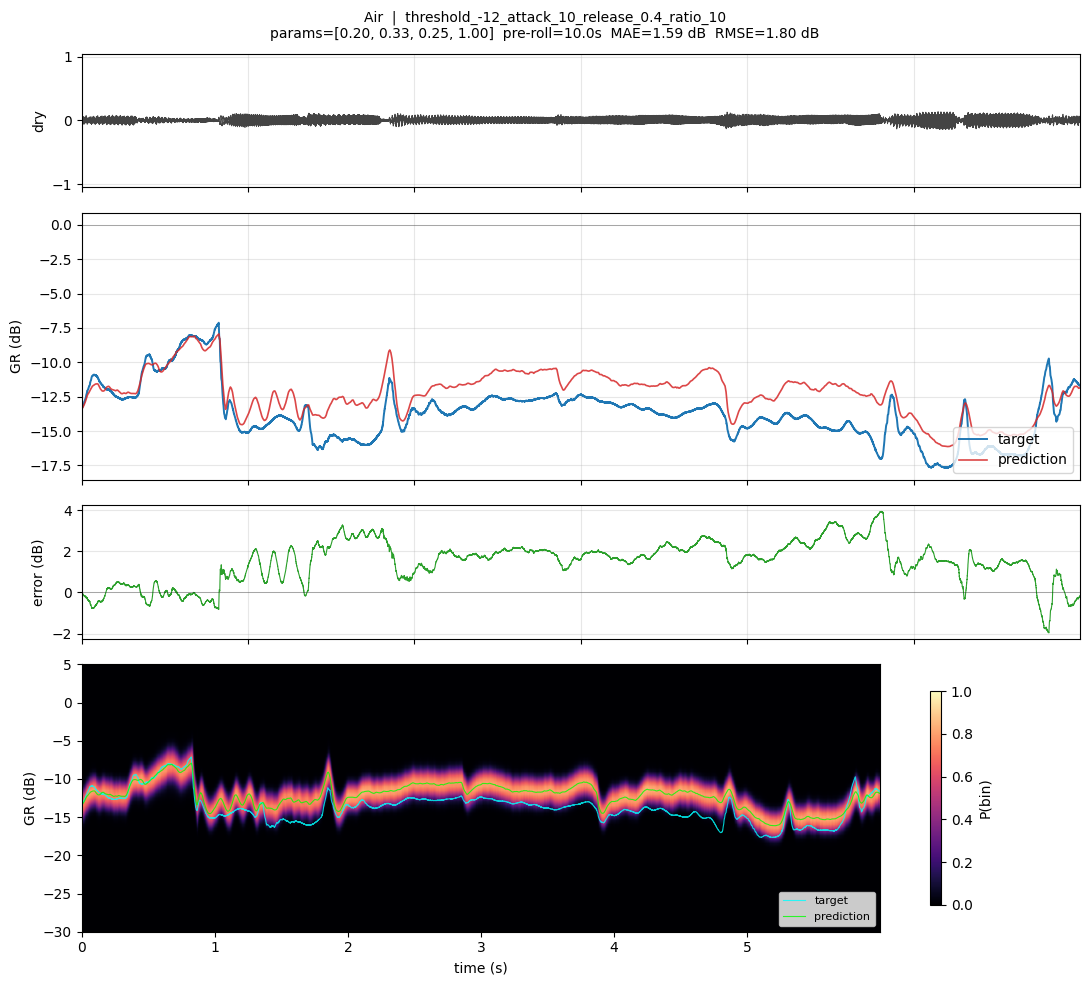

In [8]:
# Single prediction preview — held-out test song x lowest-threshold setting
song, setting = TEST_PAIRS[0]
_ = visualize_prediction(setting=setting, song=song, start_sec=30.0, duration_sec=6.0)

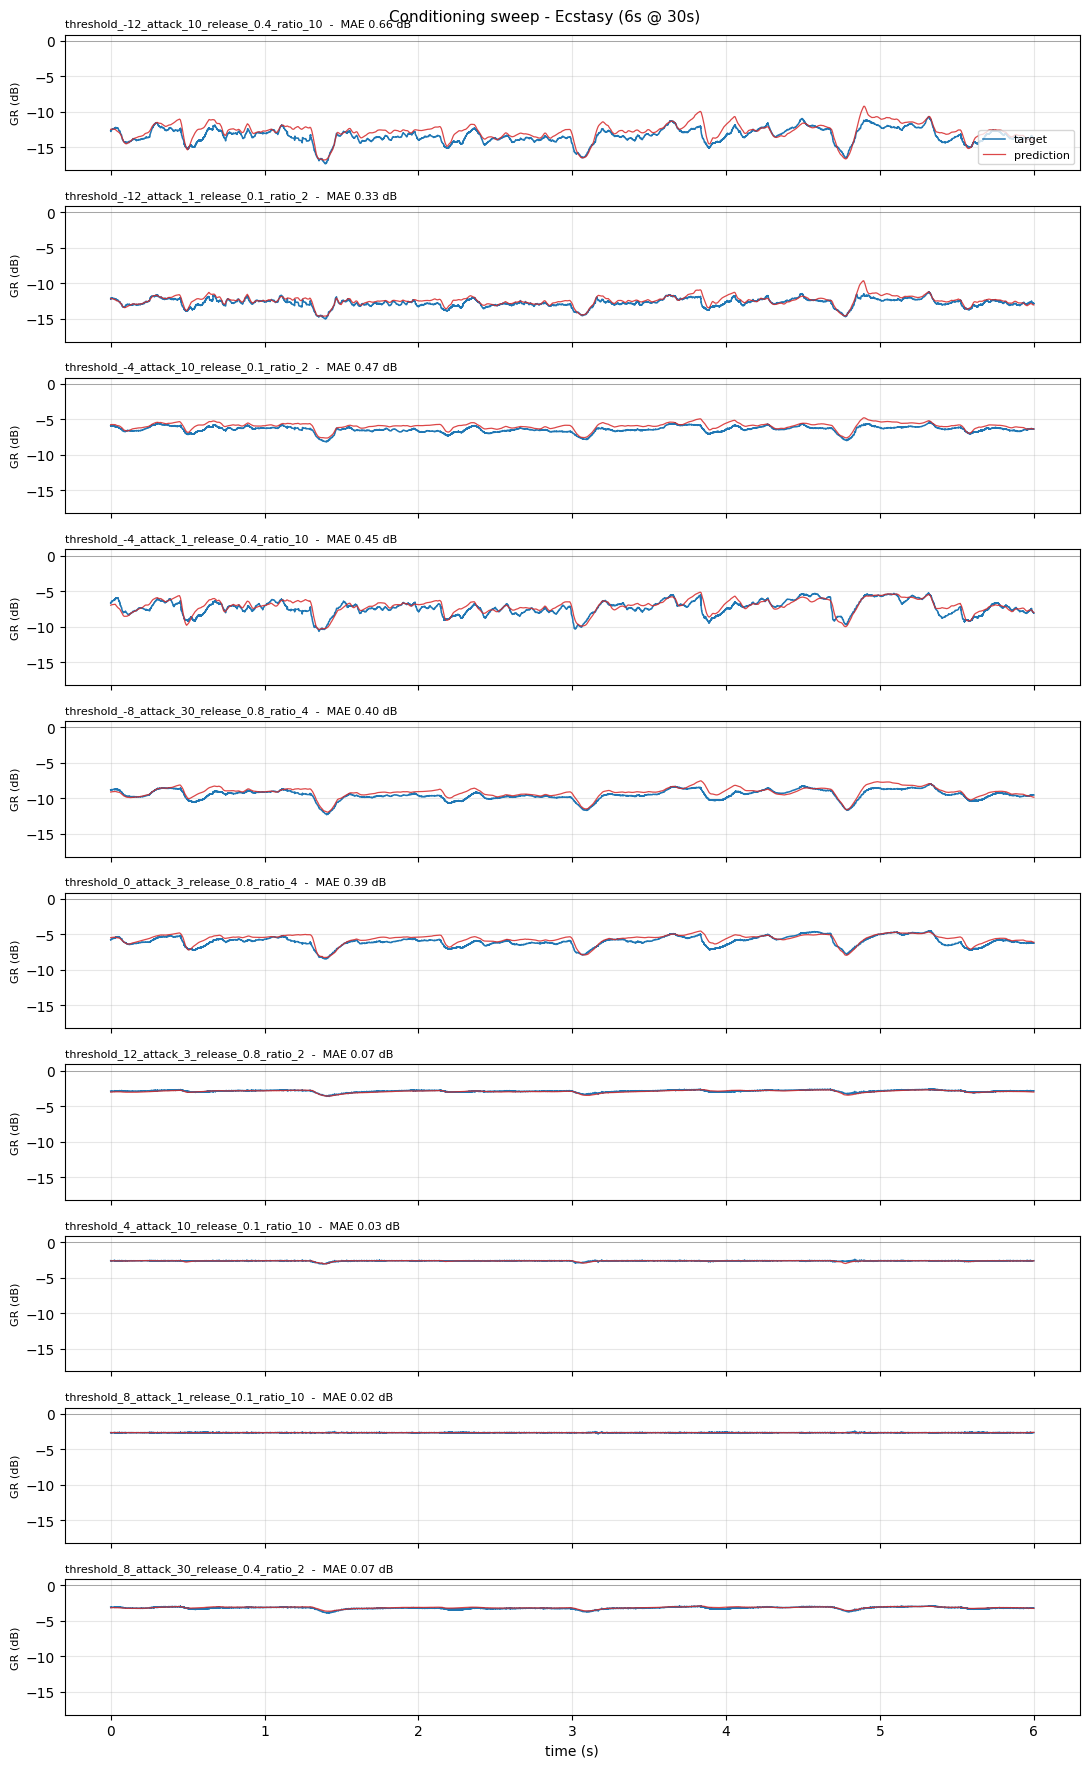

,setting,MAE (dB),RMSE (dB)
0,threshold_-12_attack_10_release_0.4_ratio_10,0.662593,0.821271
1,threshold_-12_attack_1_release_0.1_ratio_2,0.325242,0.438124
2,threshold_-4_attack_10_release_0.1_ratio_2,0.474220,0.526473
3,threshold_-4_attack_1_release_0.4_ratio_10,0.451469,0.585384
4,threshold_-8_attack_30_release_0.8_ratio_4,0.402645,0.494624
5,threshold_0_attack_3_release_0.8_ratio_4,0.386926,0.481804
6,threshold_12_attack_3_release_0.8_ratio_2,0.070584,0.084831
7,threshold_4_attack_10_release_0.1_ratio_10,0.025580,0.041708
8,threshold_8_attack_1_release_0.1_ratio_10,0.018371,0.025887
9,threshold_8_attack_30_release_0.4_ratio_2,0.070253,0.090842


,cfg_scale,MAE (dB),RMSE (dB)
0,1.00,1.137520,1.547750
1,1.25,1.433129,1.676961
2,1.50,2.455441,2.935360
3,2.00,5.325728,6.032166


In [9]:
# Conditioning sweep: validation song through all 10 settings
sweep_curves, sweep_df = conditioning_sweep(start_sec=30.0, duration_sec=6.0)

# Optional CFG sweep (runs trained with cond_dropout > 0)
if SUPPORTS_CFG:
    cfg_rows = []
    for s in (1.0, 1.25, 1.5, 2.0):
        c = predict_gr_curves(TEST_PAIRS[0][1], TEST_PAIRS[0][0],
                              start_sec=30.0, duration_sec=60.0, cfg_scale=s)
        cfg_rows.append({"cfg_scale": s, "MAE (dB)": c["mae_db"], "RMSE (dB)": c["rmse_db"]})
    display(pd.DataFrame(cfg_rows))


In [10]:
# ── 7. Audio metrics on val & test splits (TRUE stateful streaming) ──
# Streams each (song, setting) pair whole-song in chunks with BOTH recurrent
# states carried across chunks (matching TBPTT training). Wet audio is
# reconstructed as dry * 10**(GR_dB/20); metrics are duration-weighted.

MAX_EVAL_PAIRS: int | None = None    # small int for a smoke test
STREAM_CHUNK_SEC = 10.0
SAVE_CHUNK_METRICS = False
metric_cols = ["GR MAE (dB)", "MAE (L1)", "MSE (L2)", "ESR", "MR-STFT", "EDC", "M_NRMSE", "M_SF"]

sr = int(HP["sample_rate"])
step = MODEL.hop_size * MODEL.tfilm_block_size     # keep frames % tfilm block == 0
chunk_frames = int(round(STREAM_CHUNK_SEC * sr))
chunk_frames -= chunk_frames % step


@torch.no_grad()
def stream_pair_metrics(song: str, setting: str) -> list[dict]:
    """Stateful pass over a whole (song, setting) pair; per-chunk metric rows."""
    dry_path, wet_path = pair_paths(setting, song)
    params = torch.tensor([normalize_setting_params(setting)], dtype=torch.float32).to(DEVICE)
    total = _pair_num_frames(dry_path, wet_path, sr)
    state = None
    _reset_model_states(MODEL)                     # reset at song start only
    rows = []
    for ci, o in enumerate(range(0, total, chunk_frames), start=1):
        dry, wet = _read_dry_wet_segment(dry_path, wet_path, o, min(o + chunk_frames, total), sr)
        L = dry.shape[-1] - (dry.shape[-1] % step)
        if L < step:
            break
        dry, wet = dry[..., :L], wet[..., :L]
        logits, state = MODEL(dry.unsqueeze(0).to(DEVICE), params, state, return_state=True)
        gr_db = MODEL.to_db(logits, sample_len=L).squeeze(0).cpu()
        gr_target_db = gain_reduction_db(
            dry.unsqueeze(0), wet.unsqueeze(0), RMS_WIN
        ).squeeze(0).clamp(GR_DB_MIN, GR_DB_MAX)
        pred_wet = dry * _db_to_amplitude(gr_db)
        losses = compute_audio_losses(pred_wet.unsqueeze(0), wet.unsqueeze(0))
        rows.append({
            "Chunk": ci, "Start (s)": o / sr, "Duration (s)": L / sr, "Frames": L,
            "GR MAE (dB)": float((gr_db - gr_target_db).abs().mean()), **losses,
        })
    return rows


split_rows, pair_rows = [], []
for split_name, split_pairs in (("validation", VAL_PAIRS), ("test", TEST_PAIRS)):
    if MAX_EVAL_PAIRS is not None:
        split_pairs = split_pairs[:MAX_EVAL_PAIRS]
    chunk_rows = []
    for i, (song, setting) in enumerate(split_pairs, start=1):
        print(f"[{split_name} {i}/{len(split_pairs)}] {song} / {setting}")
        rows = stream_pair_metrics(song, setting)
        chunk_rows += [{"Song": song, "Setting": setting, **r} for r in rows]
        pair_rows.append({
            "Split": split_name, "Song": song, "Setting": setting,
            "Duration (s)": sum(r["Frames"] for r in rows) / sr,
            **_weighted_average_metric_rows(rows, metric_cols),
        })
        gc.collect()
    total_frames = sum(r["Frames"] for r in chunk_rows)
    split_rows.append({
        "Split": split_name, "Pairs": len(split_pairs), "Chunks": len(chunk_rows),
        "Duration (s)": total_frames / sr,
        **_weighted_average_metric_rows(chunk_rows, metric_cols),
    })
    if SAVE_CHUNK_METRICS:
        chunk_path = Path(RUN_DIR) / f"eval_audio_metrics_{split_name}_chunks.csv"
        pd.DataFrame(chunk_rows).to_csv(chunk_path, index=False)
        print(f"Saved chunk metrics -> {chunk_path}")

pair_metrics_df = pd.DataFrame(pair_rows)
audio_metrics_df = pd.DataFrame(split_rows)
pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_pairs.csv", index=False)
audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics(.csv, _pairs.csv)")

display(pair_metrics_df)
display(audio_metrics_df)

[validation 1/10] Ecstasy / threshold_-12_attack_10_release_0.4_ratio_10
[validation 2/10] Ecstasy / threshold_-12_attack_1_release_0.1_ratio_2
[validation 3/10] Ecstasy / threshold_-4_attack_10_release_0.1_ratio_2
[validation 4/10] Ecstasy / threshold_-4_attack_1_release_0.4_ratio_10
[validation 5/10] Ecstasy / threshold_-8_attack_30_release_0.8_ratio_4
[validation 6/10] Ecstasy / threshold_0_attack_3_release_0.8_ratio_4
[validation 7/10] Ecstasy / threshold_12_attack_3_release_0.8_ratio_2
[validation 8/10] Ecstasy / threshold_4_attack_10_release_0.1_ratio_10
[validation 9/10] Ecstasy / threshold_8_attack_1_release_0.1_ratio_10
[validation 10/10] Ecstasy / threshold_8_attack_30_release_0.4_ratio_2
[test 1/4] Air / threshold_-12_attack_10_release_0.4_ratio_10
[test 2/4] Air / threshold_-12_attack_1_release_0.1_ratio_2
[test 3/4] AncoraQui / threshold_-12_attack_10_release_0.4_ratio_10
[test 4/4] AncoraQui / threshold_-12_attack_1_release_0.1_ratio_2
Saved -> /Volumes/Saola's Drive/AllC

,Split,Song,Setting,Duration (s),GR MAE (dB),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,validation,Ecstasy,threshold_-12_attack_10_release_0.4_ratio_10,257.741497,0.513415,0.000955,1.974765e-06,0.032579,0.074077,0.104395,0.083248,0.117539
1,validation,Ecstasy,threshold_-12_attack_1_release_0.1_ratio_2,257.741497,0.308695,0.000959,2.033683e-06,0.026444,0.051184,0.058945,0.048965,0.102322
2,validation,Ecstasy,threshold_-4_attack_10_release_0.1_ratio_2,257.741497,0.335011,0.001968,8.730572e-06,0.025157,0.043682,0.054437,0.046734,0.061910
3,validation,Ecstasy,threshold_-4_attack_1_release_0.4_ratio_10,257.741497,0.475884,0.001817,7.250697e-06,0.030889,0.071352,0.103060,0.078988,0.116787
4,validation,Ecstasy,threshold_-8_attack_30_release_0.8_ratio_4,257.741497,0.376836,0.001362,4.151669e-06,0.026310,0.049792,0.084321,0.056141,0.065136
5,validation,Ecstasy,threshold_0_attack_3_release_0.8_ratio_4,257.741497,0.342812,0.001986,8.916773e-06,0.025875,0.047505,0.077489,0.054814,0.066094
6,validation,Ecstasy,threshold_12_attack_3_release_0.8_ratio_2,257.741497,0.093900,0.002672,1.721913e-05,0.021375,0.014532,0.019705,0.012959,0.028243
7,validation,Ecstasy,threshold_4_attack_10_release_0.1_ratio_10,257.741497,0.053756,0.002790,1.886738e-05,0.021395,0.010745,0.015737,0.011595,0.026301
8,validation,Ecstasy,threshold_8_attack_1_release_0.1_ratio_10,257.741497,0.029223,0.002784,1.888207e-05,0.021034,0.008156,0.003806,0.003947,0.023364
9,validation,Ecstasy,threshold_8_attack_30_release_0.4_ratio_2,257.741497,0.081279,0.002606,1.642063e-05,0.021561,0.013630,0.019095,0.011818,0.027632


,Split,Pairs,Chunks,Duration (s),GR MAE (dB),MAE (L1),MSE (L2),ESR,MR-STFT,EDC,M_NRMSE,M_SF
0,validation,10,260,2577.414966,0.261081,0.001990,0.000010,0.025262,0.038466,0.054099,0.040921,0.063533
1,test,4,88,857.838005,0.593557,0.001016,0.000003,0.044184,0.090448,0.287595,0.103987,0.178578
